In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

Assembling global stiffness matrix...
Applying loads...
Applying boundary conditions...
Solving system of equations...
Solution complete!

NODAL RESULTS
Node   X(mm)      Y(mm)      Z(mm)      ux(mm)       uy(mm)       uz(mm)       θx(rad)      θy(rad)      θz(rad)     
--------------------------------------------------------------------------------------------------------------------------------------------
0      0.0        0.0        0.0        0.000000     0.000000     0.000000     0.00000000   0.00000000   0.00000000  
1      6000.0     0.0        0.0        0.000000     0.000000     0.000000     0.00000000   0.00000000   0.00000000  
2      12000.0    0.0        0.0        0.000000     0.000000     0.000000     0.00000000   0.00000000   0.00000000  
3      18000.0    0.0        0.0        0.000000     0.000000     0.000000     0.00000000   0.00000000   0.00000000  
4      0.0        3000.0     0.0        0.000000     0.000000     0.000000     0.00000000   0.00000000   0.00000000 

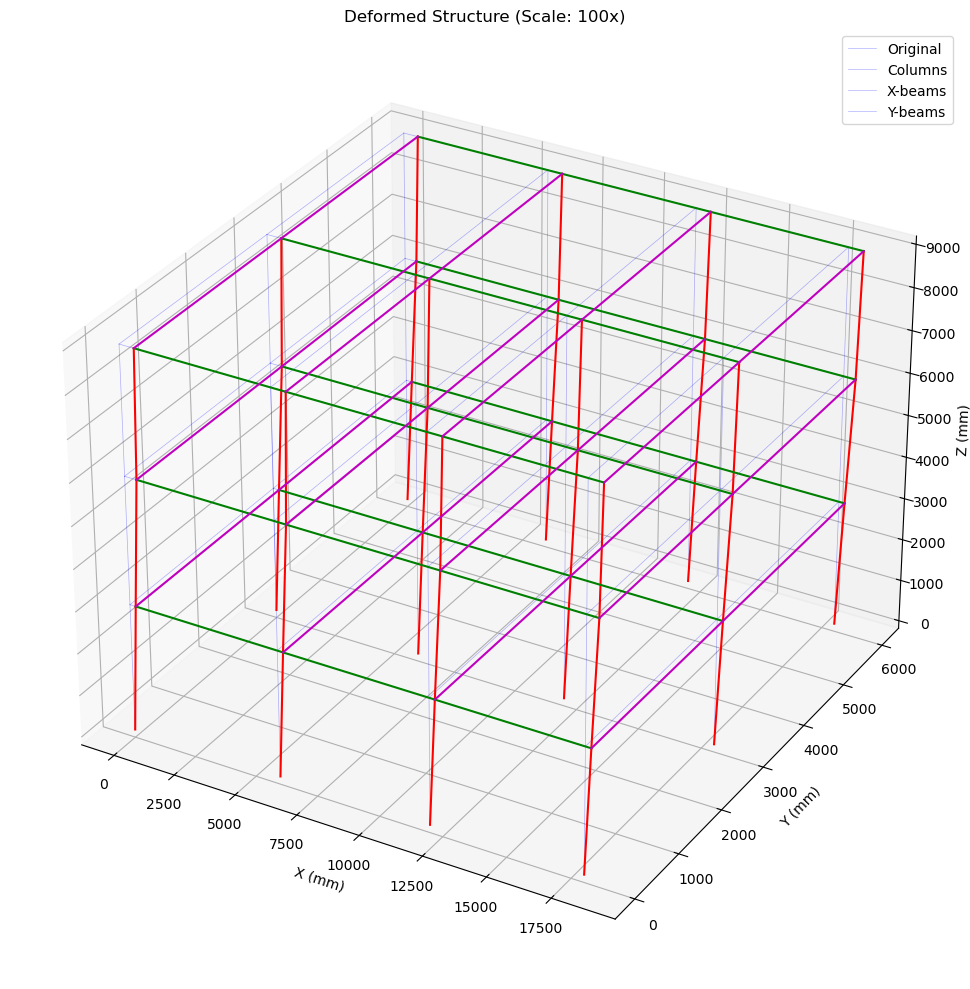

Visualization saved as 'deformation.png'


In [2]:
class SpatialFrame3D:
    def __init__(self):
        # Material properties
        self.E = 2.06e5  # MPa
        self.nu = 0.2
        self.G = self.E / (2 * (1 + self.nu))
        
        # Geometry
        self.span_x = 6000  # mm
        self.span_y = 3000  # mm
        self.height = 3000  # mm
        
        # Cross-section properties
        self.col_b = 500  # Column square section
        self.beam_b = 500  # Beam width
        self.beam_h = 500  # Beam height
        
        # Generate nodes and elements
        self.generate_nodes()
        self.generate_elements()
        
        # Initialize results storage
        self.displacements = None
        
    def generate_nodes(self):
        """Generate nodal coordinates"""
        x_coords = [0, 6000, 12000, 18000]
        y_coords = [0, 3000, 6000]
        z_coords = [0, 3000, 6000, 9000]
        
        self.nodes = []
        self.node_map = {}
        node_id = 0
        
        for k, z in enumerate(z_coords):
            for j, y in enumerate(y_coords):
                for i, x in enumerate(x_coords):
                    self.nodes.append([x, y, z])
                    self.node_map[(i, j, k)] = node_id
                    node_id += 1
        
        self.nodes = np.array(self.nodes)
        self.num_nodes = len(self.nodes)
        self.num_dofs = self.num_nodes * 6
        
    def generate_elements(self):
        """Generate element connectivity"""
        self.elements = []
        self.element_types = []  # 'col', 'beam_x', 'beam_y'
        
        # Columns (Z-direction)
        for k in range(3):  # 3 stories
            for j in range(3):  # 3 positions in Y
                for i in range(4):  # 4 positions in X
                    n1 = self.node_map[(i, j, k)]
                    n2 = self.node_map[(i, j, k+1)]
                    self.elements.append([n1, n2])
                    self.element_types.append('col')
        
        # X-direction beams
        for k in range(1, 4):  # Floors 2, 3, 4
            for j in range(3):  # 3 positions in Y
                for i in range(3):  # 3 spans
                    n1 = self.node_map[(i, j, k)]
                    n2 = self.node_map[(i+1, j, k)]
                    self.elements.append([n1, n2])
                    self.element_types.append('beam_x')
        
        # Y-direction beams
        for k in range(1, 4):  # Floors 2, 3, 4
            for i in range(4):  # 4 positions in X
                for j in range(2):  # 2 spans
                    n1 = self.node_map[(i, j, k)]
                    n2 = self.node_map[(i, j+1, k)]
                    self.elements.append([n1, n2])
                    self.element_types.append('beam_y')
        
        self.elements = np.array(self.elements)
        self.num_elements = len(self.elements)
        
    def get_section_properties(self, elem_type):
        """Calculate section properties"""
        if elem_type == 'col':
            b = h = self.col_b
        else:
            b = self.beam_b
            h = self.beam_h
        
        A = b * h
        Iy = b * h**3 / 12  # Moment of inertia about y-axis
        Iz = h * b**3 / 12  # Moment of inertia about z-axis
        J = 0.141 * b * h**3 * (1 - 0.21 * h/b * (1 - h**4/(12*b**4)))  # Torsion constant (rectangular)
        
        return A, Iy, Iz, J
    
    def transformation_matrix(self, node1, node2):
        """Generate transformation matrix from local to global coordinates"""
        coord1 = self.nodes[node1]
        coord2 = self.nodes[node2]
        
        dx = coord2[0] - coord1[0]
        dy = coord2[1] - coord1[1]
        dz = coord2[2] - coord1[2]
        L = np.sqrt(dx**2 + dy**2 + dz**2)
        
        # Direction cosines
        cx = dx / L
        cy = dy / L
        cz = dz / L
        
        # Local x-axis is along the element
        x_local = np.array([cx, cy, cz])
        
        # Choose local y and z axes
        if abs(cz) > 0.9:  # Nearly vertical
            y_global = np.array([1.0, 0.0, 0.0])
        else:
            y_global = np.array([0.0, 0.0, 1.0])
        
        z_local = np.cross(x_local, y_global)
        z_local = z_local / np.linalg.norm(z_local)
        y_local = np.cross(z_local, x_local)
        
        # Rotation matrix 3x3
        R = np.array([x_local, y_local, z_local])
        
        # Full transformation matrix 12x12
        T = np.zeros((12, 12))
        for i in range(4):
            T[i*3:(i+1)*3, i*3:(i+1)*3] = R
        
        return T, L
    
    def element_stiffness_local(self, elem_type, L):
        """Generate element stiffness matrix in local coordinates"""
        A, Iy, Iz, J = self.get_section_properties(elem_type)
        E = self.E
        G = self.G
        
        # Shear factors (for rectangular sections)
        ky = 5.0/6.0
        kz = 5.0/6.0
        
        # Shear deformation parameters
        phiy = 12 * E * Iz / (G * A * ky * L**2)
        phiz = 12 * E * Iy / (G * A * kz * L**2)
        
        k = np.zeros((12, 12))
        
        # Axial stiffness
        k[0, 0] = k[6, 6] = E * A / L
        k[0, 6] = k[6, 0] = -E * A / L
        
        # Torsional stiffness
        k[3, 3] = k[9, 9] = G * J / L
        k[3, 9] = k[9, 3] = -G * J / L
        
        # Bending about local z-axis (in xy plane)
        k[1, 1] = 12 * E * Iz / (L**3 * (1 + phiy))
        k[1, 5] = 6 * E * Iz / (L**2 * (1 + phiy))
        k[1, 7] = -12 * E * Iz / (L**3 * (1 + phiy))
        k[1, 11] = 6 * E * Iz / (L**2 * (1 + phiy))
        
        k[5, 1] = k[1, 5]
        k[5, 5] = (4 + phiy) * E * Iz / (L * (1 + phiy))
        k[5, 7] = -6 * E * Iz / (L**2 * (1 + phiy))
        k[5, 11] = (2 - phiy) * E * Iz / (L * (1 + phiy))
        
        k[7, 1] = k[1, 7]
        k[7, 5] = k[5, 7]
        k[7, 7] = 12 * E * Iz / (L**3 * (1 + phiy))
        k[7, 11] = -6 * E * Iz / (L**2 * (1 + phiy))
        
        k[11, 1] = k[1, 11]
        k[11, 5] = k[5, 11]
        k[11, 7] = k[7, 11]
        k[11, 11] = (4 + phiy) * E * Iz / (L * (1 + phiy))
        
        # Bending about local y-axis (in xz plane)
        k[2, 2] = 12 * E * Iy / (L**3 * (1 + phiz))
        k[2, 4] = -6 * E * Iy / (L**2 * (1 + phiz))
        k[2, 8] = -12 * E * Iy / (L**3 * (1 + phiz))
        k[2, 10] = -6 * E * Iy / (L**2 * (1 + phiz))
        
        k[4, 2] = k[2, 4]
        k[4, 4] = (4 + phiz) * E * Iy / (L * (1 + phiz))
        k[4, 8] = 6 * E * Iy / (L**2 * (1 + phiz))
        k[4, 10] = (2 - phiz) * E * Iy / (L * (1 + phiz))
        
        k[8, 2] = k[2, 8]
        k[8, 4] = k[4, 8]
        k[8, 8] = 12 * E * Iy / (L**3 * (1 + phiz))
        k[8, 10] = 6 * E * Iy / (L**2 * (1 + phiz))
        
        k[10, 2] = k[2, 10]
        k[10, 4] = k[4, 10]
        k[10, 8] = k[8, 10]
        k[10, 10] = (4 + phiz) * E * Iy / (L * (1 + phiz))
        
        return k
    
    def assemble_global_stiffness(self):
        """Assemble global stiffness matrix"""
        K = lil_matrix((self.num_dofs, self.num_dofs))
        
        for elem_id, (n1, n2) in enumerate(self.elements):
            elem_type = self.element_types[elem_id]
            T, L = self.transformation_matrix(n1, n2)
            k_local = self.element_stiffness_local(elem_type, L)
            k_global = T.T @ k_local @ T
            
            dofs = np.concatenate([
                np.arange(n1*6, n1*6+6),
                np.arange(n2*6, n2*6+6)
            ])
            
            for i in range(12):
                for j in range(12):
                    K[dofs[i], dofs[j]] += k_global[i, j]
        
        return K.tocsr()
    
    def apply_loads(self):
        """Apply loads to the structure"""
        F = np.zeros(self.num_dofs)
        
        # Uniform loads on beams
        for elem_id, (n1, n2) in enumerate(self.elements):
            elem_type = self.element_types[elem_id]
            
            if elem_type.startswith('beam'):
                T, L = self.transformation_matrix(n1, n2)
                p = -20  # N/mm in Z-direction
                
                # Equivalent nodal forces in global coordinates
                # Uniform load in global Z-direction
                F_z = p * L / 2
                M_y = p * L**2 / 12  # End moments
                
                if elem_type == 'beam_x':
                    # For X-direction beams
                    F[n1*6 + 2] += F_z
                    F[n2*6 + 2] += F_z
                    F[n1*6 + 4] += -M_y  # Rotation about Y
                    F[n2*6 + 4] += M_y
                else:  # beam_y
                    F[n1*6 + 2] += F_z
                    F[n2*6 + 2] += F_z
                    F[n1*6 + 3] += M_y  # Rotation about X
                    F[n2*6 + 3] += -M_y
        
        # Uniform load on columns at X=0
        w = 300  # N/mm in X-direction
        for k in range(3):  # 3 stories
            for j in range(3):  # 3 positions in Y
                i = 0  # X=0
                n1 = self.node_map[(i, j, k)]
                n2 = self.node_map[(i, j, k+1)]
                L = self.height
                
                # Equivalent nodal forces
                F_x = w * L / 2
                M_y = w * L**2 / 12
                
                F[n1*6 + 0] += F_x
                F[n2*6 + 0] += F_x
                F[n1*6 + 4] += M_y  # Rotation about Y
                F[n2*6 + 4] += -M_y
        
        return F
    
    def apply_boundary_conditions(self, K, F):
        """Apply boundary conditions (fixed base)"""
        # Bottom nodes (k=0) are fully fixed
        fixed_dofs = []
        for j in range(3):
            for i in range(4):
                node = self.node_map[(i, j, 0)]
                fixed_dofs.extend(range(node*6, node*6+6))
        
        # Remove fixed DOFs
        free_dofs = np.setdiff1d(np.arange(self.num_dofs), fixed_dofs)
        
        K_reduced = K[free_dofs, :][:, free_dofs]
        F_reduced = F[free_dofs]
        
        return K_reduced, F_reduced, free_dofs
    
    def solve(self):
        """Solve the FEM problem"""
        print("Assembling global stiffness matrix...")
        K = self.assemble_global_stiffness()
        
        print("Applying loads...")
        F = self.apply_loads()
        
        print("Applying boundary conditions...")
        K_reduced, F_reduced, free_dofs = self.apply_boundary_conditions(K, F)
        
        print("Solving system of equations...")
        U_reduced = spsolve(K_reduced, F_reduced)
        
        # Reconstruct full displacement vector
        self.displacements = np.zeros(self.num_dofs)
        self.displacements[free_dofs] = U_reduced
        
        print("Solution complete!")
        return self.displacements
    
    def get_nodal_results(self):
        """Extract nodal displacements and rotations"""
        results = []
        for node_id in range(self.num_nodes):
            x, y, z = self.nodes[node_id]
            ux, uy, uz = self.displacements[node_id*6:node_id*6+3]
            rx, ry, rz = self.displacements[node_id*6+3:node_id*6+6]
            results.append([node_id, x, y, z, ux, uy, uz, rx, ry, rz])
        return np.array(results)
    
    def get_element_results(self, num_points=200):
        """Get displacements along elements at specified intervals"""
        element_results = []
        
        for elem_id, (n1, n2) in enumerate(self.elements):
            elem_type = self.element_types[elem_id]
            T, L = self.transformation_matrix(n1, n2)
            
            # Get nodal displacements in global coordinates
            u_global = np.concatenate([
                self.displacements[n1*6:n1*6+6],
                self.displacements[n2*6:n2*6+6]
            ])
            
            # Transform to local coordinates
            u_local = T @ u_global
            
            # Sample along element every 200mm
            num_samples = int(L / num_points) + 1
            coord1 = self.nodes[n1]
            coord2 = self.nodes[n2]
            
            for i in range(num_samples + 1):
                if i == num_samples:
                    xi = 1.0
                else:
                    xi = min(i * num_points / L, 1.0)
                
                # Shape functions
                N1 = 1 - xi
                N2 = xi
                
                # Linear interpolation (simplified)
                u_loc = u_local[:6] * N1 + u_local[6:] * N2
                
                # Position along element
                pos = coord1 + (coord2 - coord1) * xi
                
                # Transform back to global
                R = T[:3, :3]
                u_glob = np.zeros(6)
                u_glob[:3] = R.T @ u_loc[:3]
                u_glob[3:] = R.T @ u_loc[3:]
                
                element_results.append([
                    elem_id, elem_type, pos[0], pos[1], pos[2],
                    u_glob[0], u_glob[1], u_glob[2],
                    u_glob[3], u_glob[4], u_glob[5]
                ])
        
        return element_results
    
    def visualize_deformation(self, scale=100):
        """Visualize the deformed structure"""
        fig = plt.figure(figsize=(15, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Original structure
        for elem_id, (n1, n2) in enumerate(self.elements):
            coord1 = self.nodes[n1]
            coord2 = self.nodes[n2]
            ax.plot3D([coord1[0], coord2[0]], 
                     [coord1[1], coord2[1]], 
                     [coord1[2], coord2[2]], 'b-', alpha=0.3, linewidth=0.5)
        
        # Deformed structure
        for elem_id, (n1, n2) in enumerate(self.elements):
            coord1 = self.nodes[n1] + self.displacements[n1*6:n1*6+3] * scale
            coord2 = self.nodes[n2] + self.displacements[n2*6:n2*6+3] * scale
            
            elem_type = self.element_types[elem_id]
            if elem_type == 'col':
                color = 'r'
            elif elem_type == 'beam_x':
                color = 'g'
            else:
                color = 'm'
            
            ax.plot3D([coord1[0], coord2[0]], 
                     [coord1[1], coord2[1]], 
                     [coord1[2], coord2[2]], 
                     color=color, linewidth=1.5)
        
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(f'Deformed Structure (Scale: {scale}x)')
        ax.legend(['Original', 'Columns', 'X-beams', 'Y-beams'])
        
        plt.tight_layout()
        plt.savefig('deformation.png', dpi=150)
        plt.show()

# Main execution
if __name__ == "__main__":
    # Create and solve the structure
    frame = SpatialFrame3D()
    displacements = frame.solve()
    
    # Get nodal results
    print("\n" + "="*80)
    print("NODAL RESULTS")
    print("="*80)
    nodal_results = frame.get_nodal_results()
    print(f"{'Node':<6} {'X(mm)':<10} {'Y(mm)':<10} {'Z(mm)':<10} {'ux(mm)':<12} {'uy(mm)':<12} {'uz(mm)':<12} {'θx(rad)':<12} {'θy(rad)':<12} {'θz(rad)':<12}")
    print("-"*140)
    for row in nodal_results:
        print(f"{int(row[0]):<6} {row[1]:<10.1f} {row[2]:<10.1f} {row[3]:<10.1f} "
              f"{row[4]:<12.6f} {row[5]:<12.6f} {row[6]:<12.6f} "
              f"{row[7]:<12.8f} {row[8]:<12.8f} {row[9]:<12.8f}")
    
    # Get element results
    print("\n" + "="*80)
    print("ELEMENT RESULTS (every 200mm)")
    print("="*80)
    element_results = frame.get_element_results(200)
    print(f"{'Elem':<6} {'Type':<8} {'X(mm)':<10} {'Y(mm)':<10} {'Z(mm)':<10} "
          f"{'ux(mm)':<12} {'uy(mm)':<12} {'uz(mm)':<12} "
          f"{'θx(rad)':<12} {'θy(rad)':<12} {'θz(rad)':<12}")
    print("-"*150)
    for row in element_results[:100]:  # Show first 100 points
        print(f"{int(row[0]):<6} {row[1]:<8} {row[2]:<10.1f} {row[3]:<10.1f} {row[4]:<10.1f} "
              f"{row[5]:<12.6f} {row[6]:<12.6f} {row[7]:<12.6f} "
              f"{row[8]:<12.8f} {row[9]:<12.8f} {row[10]:<12.8f}")
    
    print(f"\n... (Total {len(element_results)} points calculated)")
    
    # Summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"Maximum displacement in X: {np.max(np.abs(displacements[0::6])):.6f} mm")
    print(f"Maximum displacement in Y: {np.max(np.abs(displacements[1::6])):.6f} mm")
    print(f"Maximum displacement in Z: {np.max(np.abs(displacements[2::6])):.6f} mm")
    print(f"Maximum rotation about X: {np.max(np.abs(displacements[3::6])):.8f} rad")
    print(f"Maximum rotation about Y: {np.max(np.abs(displacements[4::6])):.8f} rad")
    print(f"Maximum rotation about Z: {np.max(np.abs(displacements[5::6])):.8f} rad")
    
    # Visualize
    print("\nGenerating deformation visualization...")
    frame.visualize_deformation(scale=100)
    print("Visualization saved as 'deformation.png'")